In [30]:
import pandas as pd 
import numpy as np 
import os 
import matplotlib.pyplot as plt

In [31]:
df = pd.read_csv("../data/processed/processed_data.csv")

#fetch the clean csv file

In [32]:
df.head()

,Open Time,Open Price,High Price,Low Price,Close Price,Volume,Change_1min,Change_3min,Change_5min,Vol_avg_15min,Volume_spike_ratio,High_Low_spread,Relative_strength_index,Target_Pump
0,2025-03-19 14:15:00,84103.77,84166.56,84084.86,84094.26,10.67051,-0.000113,-0.000591,-0.002496,49.730561,0.214566,0.000972,31.699495,0
1,2025-03-19 14:16:00,84094.26,84150.95,84080.55,84150.95,33.97506,0.000674,0.001218,-0.000971,50.617851,0.671207,0.000837,39.811202,0
2,2025-03-19 14:17:00,84150.95,84198.12,84138.01,84169.99,8.40472,0.000226,0.000787,0.000309,47.178076,0.178149,0.000714,42.290237,0
3,2025-03-19 14:18:00,84169.99,84228.00,84169.99,84200.44,13.04738,0.000362,0.001263,0.001807,47.237625,0.276207,0.000689,46.112826,0
4,2025-03-19 14:19:00,84200.44,84295.99,84187.37,84292.12,8.04872,0.001089,0.001678,0.002239,46.333428,0.173713,0.001290,55.640139,0


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 525592 entries, 0 to 525591
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Open Time                525592 non-null  str    
 1   Open Price               525592 non-null  float64
 2   High Price               525592 non-null  float64
 3   Low Price                525592 non-null  float64
 4   Close Price              525592 non-null  float64
 5   Volume                   525592 non-null  float64
 6   Change_1min              525592 non-null  float64
 7   Change_3min              525592 non-null  float64
 8   Change_5min              525592 non-null  float64
 9   Vol_avg_15min            525592 non-null  float64
 10  Volume_spike_ratio       525592 non-null  float64
 11  High_Low_spread          525592 non-null  float64
 12  Relative_strength_index  525592 non-null  float64
 13  Target_Pump              525592 non-null  int64  
dtypes: float64(12),

In [34]:
df['Open Time'] = pd.to_datetime(df['Open Time'])

In [35]:
df.set_index('Open Time' , inplace=True)
print(df.index.name)

Open Time


In [36]:
df['Hour_of_day'] = df.index.hour
df['Day_of_week'] = df.index.day_of_week

In [37]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 525592 entries, 2025-03-19 14:15:00 to 2026-03-19 14:06:00
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Open Price               525592 non-null  float64
 1   High Price               525592 non-null  float64
 2   Low Price                525592 non-null  float64
 3   Close Price              525592 non-null  float64
 4   Volume                   525592 non-null  float64
 5   Change_1min              525592 non-null  float64
 6   Change_3min              525592 non-null  float64
 7   Change_5min              525592 non-null  float64
 8   Vol_avg_15min            525592 non-null  float64
 9   Volume_spike_ratio       525592 non-null  float64
 10  High_Low_spread          525592 non-null  float64
 11  Relative_strength_index  525592 non-null  float64
 12  Target_Pump              525592 non-null  int64  
 13  Hour_of_day              525592 non-

In [38]:
df.columns

Index(['Open Price', 'High Price', 'Low Price', 'Close Price', 'Volume',
       'Change_1min', 'Change_3min', 'Change_5min', 'Vol_avg_15min',
       'Volume_spike_ratio', 'High_Low_spread', 'Relative_strength_index',
       'Target_Pump', 'Hour_of_day', 'Day_of_week'],
      dtype='str')

In [39]:
from sklearn.model_selection import train_test_split

y = df['Target_Pump']
x = df.drop(columns=['Target_Pump' , 'Change_5min' , 'Volume_spike_ratio' , 'Change_1min' , 'Change_3min' , 'Volume_spike_ratio' , 'High_Low_spread'])
x_shift = x.shift(5)
x_shift = x_shift.dropna()
y_shift = y.iloc[5:]


In [40]:
total_rows = len(df)
train_end = int(total_rows * 0.80)
val_end = int(total_rows * 0.90)

# 80% train , 10 % val and 10% test

x_train , y_train = x_shift.iloc[:train_end] , y_shift.iloc[:train_end]
x_val , y_val = x_shift.iloc[train_end:val_end] , y_shift.iloc[train_end:val_end]
x_test , y_test = x_shift.iloc[val_end:] , y_shift.iloc[val_end:]

In [41]:
# from pandas.plotting import scatter_matrix

# attributes = ['Open Price', 'High Price', 'Low Price', 'Close Price', 'Volume',
#        'Change_1min', 'Change_3min', 'Change_5min', 'Vol_avg_15min',
#        'Volume_spike_ratio', 'High_Low_spread', 'Relative_strength_index',
#        'Target_Pump', 'Hour_of_day', 'Day_of_week']

# scatter_matrix(df[attributes])
# plt.tight_layout()
# plt.show()




In [42]:
(y_train == 1).sum()

np.int64(262)

In [43]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV  

tree = DecisionTreeClassifier(random_state=42 , class_weight='balanced')

param_list = {
    'max_depth' : [5 , 10 , 20],
    'min_samples_split' : [2 , 10 , 50],
    'min_samples_leaf' : [1,5,10]
}

random_search = RandomizedSearchCV(
    estimator=tree,
    param_distributions=param_list,
    n_jobs=-1,
    verbose=2,
    scoring='recall',
    cv=5
)

random_search.fit(x_train , y_train )


Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=10, min_samples_leaf=5, min_samples_split=2; total time=   4.4s
[CV] END max_depth=20, min_samples_leaf=5, min_samples_split=2; total time=   4.6s
[CV] END max_depth=10, min_samples_leaf=5, min_samples_split=2; total time=   4.7s
[CV] END max_depth=10, min_samples_leaf=5, min_samples_split=2; total time=   4.8s
[CV] END max_depth=10, min_samples_leaf=5, min_samples_split=2; total time=   4.9s
[CV] END max_depth=10, min_samples_leaf=5, min_samples_split=2; total time=   4.9s
[CV] END max_depth=20, min_samples_leaf=5, min_samples_split=2; total time=   5.1s
[CV] END max_depth=20, min_samples_leaf=10, min_samples_split=10; total time=   5.0s
[CV] END max_depth=20, min_samples_leaf=5, min_samples_split=2; total time=   6.4s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2; total time=   6.5s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2; total time=   6.6s
[CV] END max_depth=10, m

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 5, ...], 'min_samples_split': [2, 10, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` defau

In [44]:
random_search.best_params_

{'min_samples_split': 2, 'min_samples_leaf': 10, 'max_depth': 5}

In [45]:
random_search.best_score_

np.float64(0.5324383164005806)

In [46]:
tree_best = random_search.best_estimator_
tree_best.fit(x_train , y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [47]:
from sklearn.metrics import recall_score

y_pred = tree_best.predict(x_val)
print(f"Recall score : {recall_score(y_val , y_pred):.3f}" )

Recall score : 0.617


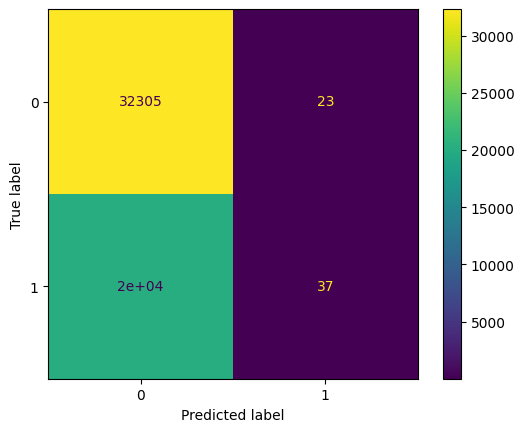

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay , confusion_matrix

conf_mat = confusion_matrix(y_pred , y_val)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat)
disp.plot()
plt.show()

In [49]:
from sklearn.metrics import precision_score

print(f"Precision : {precision_score(y_val , y_pred)}")

Precision : 0.0018288764766941823


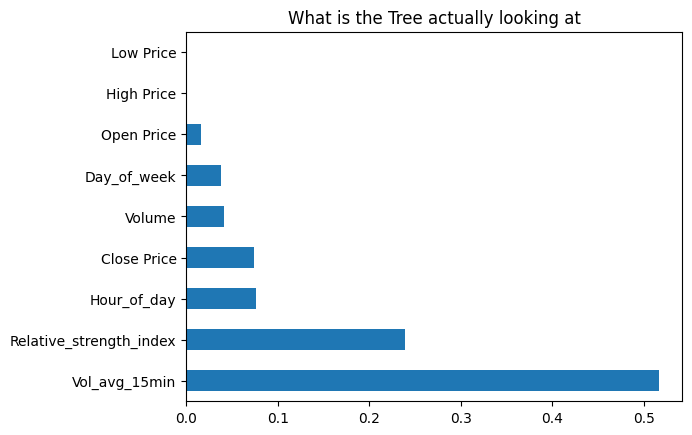

In [50]:

feat_importances = pd.Series(tree_best.feature_importances_, index=x.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title("What is the Tree actually looking at")
plt.show()

In [51]:
from xgboost import XGBClassifier

In [ ]:
ratio = (y_train == 0).sum()/(y_train == 1).sum()

sqrt_ratio = np.sqrt(ratio)
xg_boost = XGBClassifier(scale_pos_weight=sqrt_ratio ,
                         random_state = 42,
                         verbosity=2)


xg_boost.fit(x_train , y_train)


[18:11:37] INFO: /__w/xgboost/xgboost/src/data/iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (420473, 9, 3784257).
Recall : 0.0
Precision : 0.0


In [54]:
recall_score(xg_boost.predict(x_train) , y_train)

0.8343949044585988

In [55]:

y_pred = xg_boost.predict(x_val)
print(f"Recall : {recall_score(y_val , y_pred)}")
print(f"Precision : {precision_score(y_val , y_pred)}")


Recall : 0.0
Precision : 0.0
